In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────
DATA_DIR    = "tdcsfog_csvs"
FS          = 128
WINDOW_SIZE = 192          # 1.5 s  — same as Stage 1

# Pre-onset safety gap: skip this many samples before episode start
# to avoid the ambiguous transition zone
SAFETY_GAP  = 64           # 0.5 s

# A pre-onset window is only valid if its FOG ratio is below this
FOG_CLEAN_THRESH = 0.2

AXES          = ["AccV", "AccML", "AccAP"]
TRIGGER_COLS  = ["StartHesitation", "Turn", "Walking"]
TRIGGER_TYPES = ["StartHesitation", "Turn", "Walking"]
COLORS        = {"StartHesitation": "#e63946",
                 "Turn":            "#457b9d",
                 "Walking":         "#2a9d8f"}

print(f"Safety gap  : {SAFETY_GAP/FS:.2f} s")
print(f"Window size : {WINDOW_SIZE/FS:.2f} s")
print(f"Pre-onset window covers: {(WINDOW_SIZE+SAFETY_GAP)/FS:.2f}s before episode start")

Safety gap  : 0.50 s
Window size : 1.50 s
Pre-onset window covers: 2.00s before episode start


In [2]:
FREQS = np.fft.rfftfreq(WINDOW_SIZE, d=1/FS)  # shared frequency bins

def compute_features(win, trigger):
    """
    win     : (192, 3) float32  — pre-onset raw signal
    trigger : str               — dominant trigger label
    Returns : dict of scalar features
    """
    rec = {"trigger": trigger}

    for ax_idx, ax_name in enumerate(AXES):
        sig  = win[:, ax_idx]
        jerk = np.diff(sig)

        # Remove DC offset before FFT so gravity doesn't dominate
        sig_detrended = sig - sig.mean()
        fft_mag = np.abs(np.fft.rfft(sig_detrended))

        rec[f"energy_{ax_name}"]            = float(np.mean(sig ** 2))
        rec[f"var_{ax_name}"]               = float(np.var(sig))
        rec[f"mean_abs_jerk_{ax_name}"]     = float(np.mean(np.abs(jerk)))
        rec[f"dom_freq_{ax_name}"]          = float(FREQS[np.argmax(fft_mag)])
        rec[f"spectral_entropy_{ax_name}"]  = float(_spectral_entropy(fft_mag))

    # Cross-axis correlations
    rec["corr_AccV_AccML"]  = float(np.corrcoef(win[:,0], win[:,1])[0,1])
    rec["corr_AccV_AccAP"]  = float(np.corrcoef(win[:,0], win[:,2])[0,1])
    rec["corr_AccML_AccAP"] = float(np.corrcoef(win[:,1], win[:,2])[0,1])

    return rec


def _spectral_entropy(fft_mag):
    """Normalised spectral entropy — low = periodic signal, high = noise."""
    power = fft_mag ** 2
    total = power.sum()
    if total == 0:
        return 0.0
    p = power / total
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)) / np.log(len(p) + 1e-8))


print("Feature functions ready.")

Feature functions ready.


In [3]:
def find_episodes(df):
    """
    Returns list of (start_idx, end_idx, dominant_trigger)
    where indices are sample positions in df.
    """
    fog = (
        (df["StartHesitation"] == 1) |
        (df["Turn"]            == 1) |
        (df["Walking"]         == 1)
    ).astype(int).values

    sh = df["StartHesitation"].values
    tu = df["Turn"].values
    wa = df["Walking"].values

    episodes = []
    in_fog   = False
    ep_start = 0

    for i in range(len(fog)):
        if fog[i] == 1 and not in_fog:
            ep_start = i
            in_fog   = True
        elif fog[i] == 0 and in_fog:
            ep_end = i
            # dominant trigger by sample count
            sh_c = sh[ep_start:ep_end].sum()
            tu_c = tu[ep_start:ep_end].sum()
            wa_c = wa[ep_start:ep_end].sum()
            trig = TRIGGER_TYPES[np.argmax([sh_c, tu_c, wa_c])]
            episodes.append((ep_start, ep_end, trig))
            in_fog = False

    # close last episode
    if in_fog:
        ep_end = len(fog)
        sh_c = sh[ep_start:ep_end].sum()
        tu_c = tu[ep_start:ep_end].sum()
        wa_c = wa[ep_start:ep_end].sum()
        trig = TRIGGER_TYPES[np.argmax([sh_c, tu_c, wa_c])]
        episodes.append((ep_start, ep_end, trig))

    return episodes


print("Episode finder ready.")

Episode finder ready.


In [4]:
csv_files = [
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if f.endswith(".csv")
]

records         = []   # only feature dicts — stays small
skipped_short   = 0    # not enough signal before episode
skipped_dirty   = 0    # pre-onset window still has FOG
total_episodes  = 0

required = set(AXES + TRIGGER_COLS)

for path in tqdm(csv_files, desc="Processing files"):
    df = pd.read_csv(path)

    if not required.issubset(df.columns):
        continue

    signals = df[AXES].values.astype(np.float32)   # (T, 3)
    fog_arr = (
        (df["StartHesitation"].values == 1) |
        (df["Turn"].values            == 1) |
        (df["Walking"].values         == 1)
    ).astype(np.float32)

    episodes = find_episodes(df)
    total_episodes += len(episodes)

    for (ep_start, ep_end, trig) in episodes:

        # ── Define pre-onset window boundaries ──────────────────
        pre_end   = ep_start - SAFETY_GAP         # end of pre-onset window
        pre_start = pre_end  - WINDOW_SIZE         # start of pre-onset window

        # Validation 1: enough signal before episode
        if pre_start < 0:
            skipped_short += 1
            continue

        # Validation 2: window must be clean (no FOG activity)
        fog_ratio = fog_arr[pre_start:pre_end].mean()
        if fog_ratio > FOG_CLEAN_THRESH:
            skipped_dirty += 1
            continue

        # ── Extract window, compute features, discard window ────
        win = signals[pre_start:pre_end]           # (192, 3)
        rec = compute_features(win, trig)
        records.append(rec)

        # Explicitly free the window
        del win

    # Free per-file data
    del signals, fog_arr
    gc.collect()

feat_df = pd.DataFrame(records)

print(f"\nTotal episodes found : {total_episodes}")
print(f"Skipped (too short)  : {skipped_short}")
print(f"Skipped (dirty)      : {skipped_dirty}")
print(f"Valid pre-onset wins : {len(feat_df)}")
print(f"Feature matrix shape : {feat_df.shape}")
print("\nTrigger distribution:")
print(feat_df["trigger"].value_counts())

Processing files: 100%|██████████| 833/833 [01:16<00:00, 10.88it/s]



Total episodes found : 1132
Skipped (too short)  : 2
Skipped (dirty)      : 151
Valid pre-onset wins : 979
Feature matrix shape : (979, 19)

Trigger distribution:
trigger
Turn               814
StartHesitation     86
Walking             79
Name: count, dtype: int64


In [5]:
# Re-collect windows per trigger for mean shape plot only
# Store running sum + count, not individual windows

sum_wins  = {t: np.zeros((WINDOW_SIZE, 3), dtype=np.float64) for t in TRIGGER_TYPES}
sum_sq    = {t: np.zeros((WINDOW_SIZE, 3), dtype=np.float64) for t in TRIGGER_TYPES}
counts    = {t: 0 for t in TRIGGER_TYPES}

for path in tqdm(csv_files, desc="Computing mean shapes"):
    df = pd.read_csv(path)
    if not required.issubset(df.columns):
        continue

    signals = df[AXES].values.astype(np.float32)
    fog_arr = (
        (df["StartHesitation"].values == 1) |
        (df["Turn"].values            == 1) |
        (df["Walking"].values         == 1)
    ).astype(np.float32)

    for (ep_start, ep_end, trig) in find_episodes(df):
        pre_end   = ep_start - SAFETY_GAP
        pre_start = pre_end  - WINDOW_SIZE
        if pre_start < 0:
            continue
        if fog_arr[pre_start:pre_end].mean() > FOG_CLEAN_THRESH:
            continue

        win = signals[pre_start:pre_end].astype(np.float64)
        sum_wins[trig] += win
        sum_sq[trig]   += win ** 2
        counts[trig]   += 1
        del win

    del signals, fog_arr
    gc.collect()

# Compute mean and std from running sums
mean_wins = {}
std_wins  = {}
for t in TRIGGER_TYPES:
    n = counts[t]
    if n > 0:
        mean_wins[t] = sum_wins[t] / n
        std_wins[t]  = np.sqrt(np.maximum(sum_sq[t]/n - mean_wins[t]**2, 0))

del sum_wins, sum_sq
gc.collect()
print("Mean shapes computed.")
for t in TRIGGER_TYPES:
    print(f"  {t:<20}: {counts[t]} windows")

Computing mean shapes: 100%|██████████| 833/833 [01:04<00:00, 12.85it/s]


Mean shapes computed.
  StartHesitation     : 86 windows
  Turn                : 814 windows
  Walking             : 79 windows


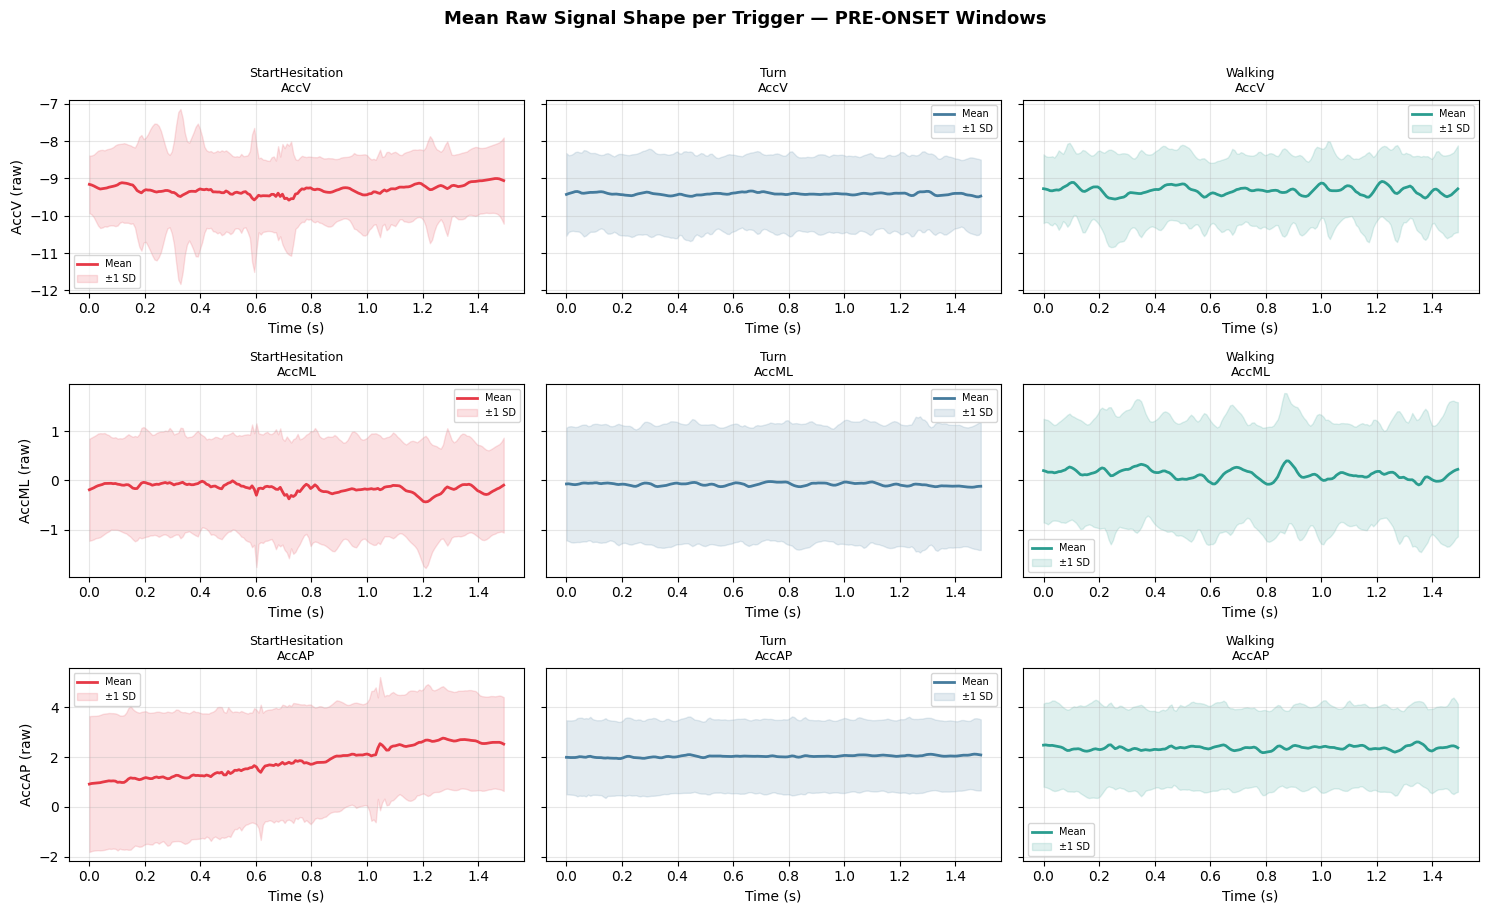

In [6]:
time_axis = np.arange(WINDOW_SIZE) / FS

fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharey='row')

for row, ax_name in enumerate(AXES):
    for col, trig in enumerate(TRIGGER_TYPES):
        ax    = axes[row][col]
        mean  = mean_wins[trig][:, row]
        std   = std_wins[trig][:, row]
        color = COLORS[trig]

        ax.plot(time_axis, mean, color=color, linewidth=2, label="Mean")
        ax.fill_between(time_axis, mean-std, mean+std,
                        color=color, alpha=0.15, label="±1 SD")
        ax.set_title(f"{trig}\n{ax_name}", fontsize=9)
        ax.set_xlabel("Time (s)")
        if col == 0:
            ax.set_ylabel(f"{ax_name} (raw)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

plt.suptitle("Mean Raw Signal Shape per Trigger — PRE-ONSET Windows",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


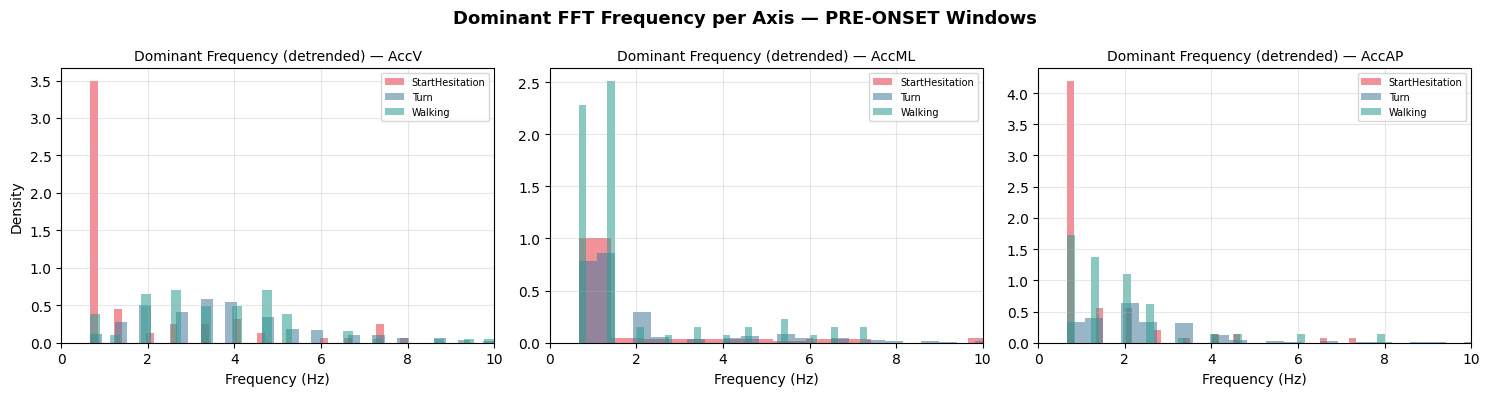

In [7]:
fig, axes_grid = plt.subplots(1, 3, figsize=(15, 4))

for col, ax_name in enumerate(AXES):
    ax = axes_grid[col]
    for trig in TRIGGER_TYPES:
        vals = feat_df[feat_df["trigger"] == trig][f"dom_freq_{ax_name}"]
        ax.hist(vals, bins=40, alpha=0.55,
                color=COLORS[trig], label=trig, density=True)
    ax.set_title(f"Dominant Frequency (detrended) — {ax_name}", fontsize=10)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_xlim(0, 10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel("Density")

plt.suptitle("Dominant FFT Frequency per Axis — PRE-ONSET Windows",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3330/1855486677.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feat_df, x="trigger", y=f"energy_{ax_name}",
/tmp/ipykernel_3330/1855486677.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feat_df, x="trigger", y=f"var_{ax_name}",
/tmp/ipykernel_3330/1855486677.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feat_df, x="trigger", y=f"energy_{ax_name}",
/tmp/ipykernel_3330/1855486677.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

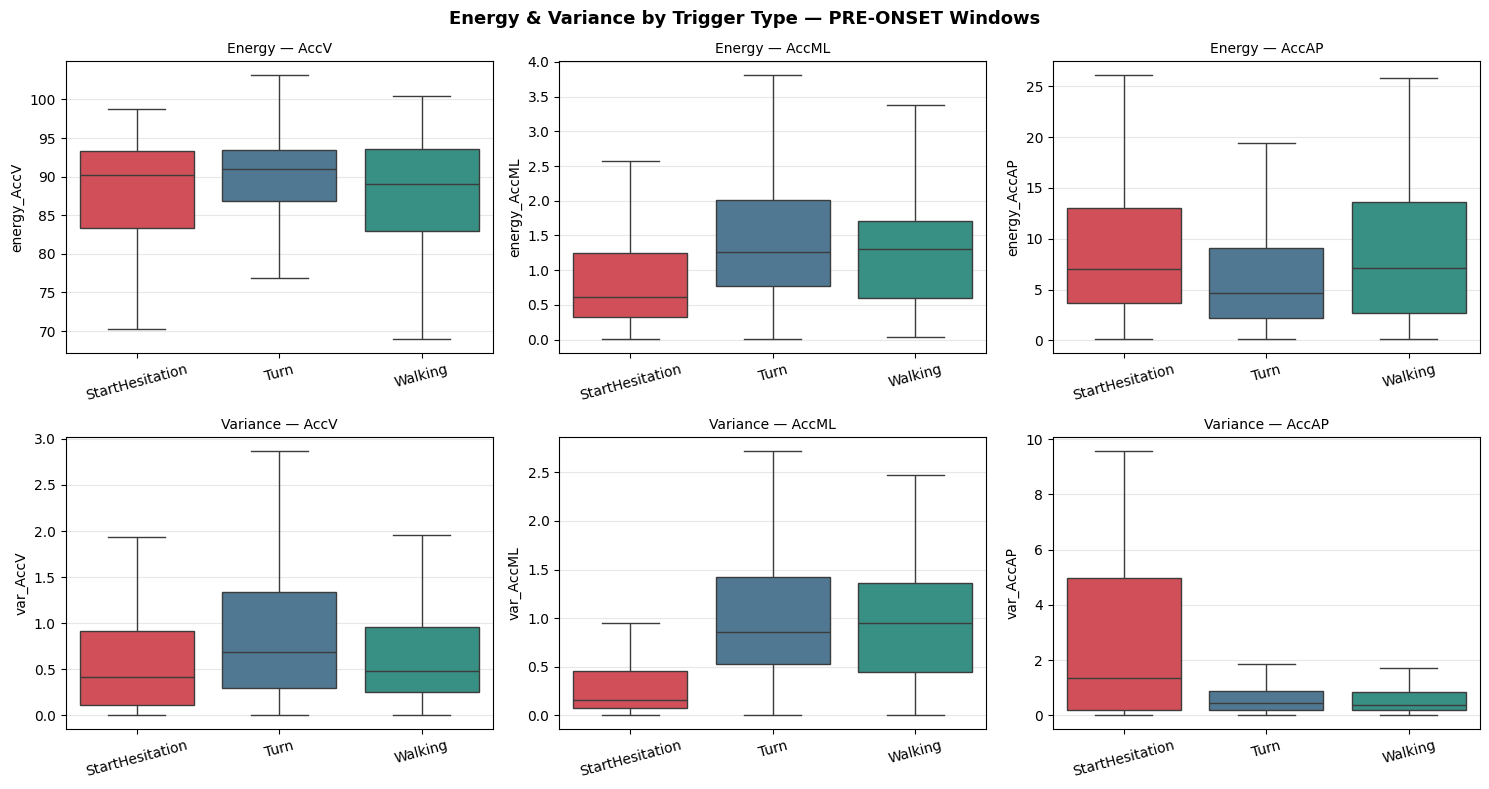

In [8]:
fig, axes_grid = plt.subplots(2, 3, figsize=(15, 8))

for col, ax_name in enumerate(AXES):

    # Energy
    ax = axes_grid[0][col]
    sns.boxplot(data=feat_df, x="trigger", y=f"energy_{ax_name}",
                palette=COLORS, order=TRIGGER_TYPES,
                showfliers=False, ax=ax)
    ax.set_title(f"Energy — {ax_name}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

    # Variance
    ax = axes_grid[1][col]
    sns.boxplot(data=feat_df, x="trigger", y=f"var_{ax_name}",
                palette=COLORS, order=TRIGGER_TYPES,
                showfliers=False, ax=ax)
    ax.set_title(f"Variance — {ax_name}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Energy & Variance by Trigger Type — PRE-ONSET Windows",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3330/2421139724.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=feat_df, x="trigger",
/tmp/ipykernel_3330/2421139724.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=feat_df, x="trigger",
/tmp/ipykernel_3330/2421139724.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=feat_df, x="trigger",


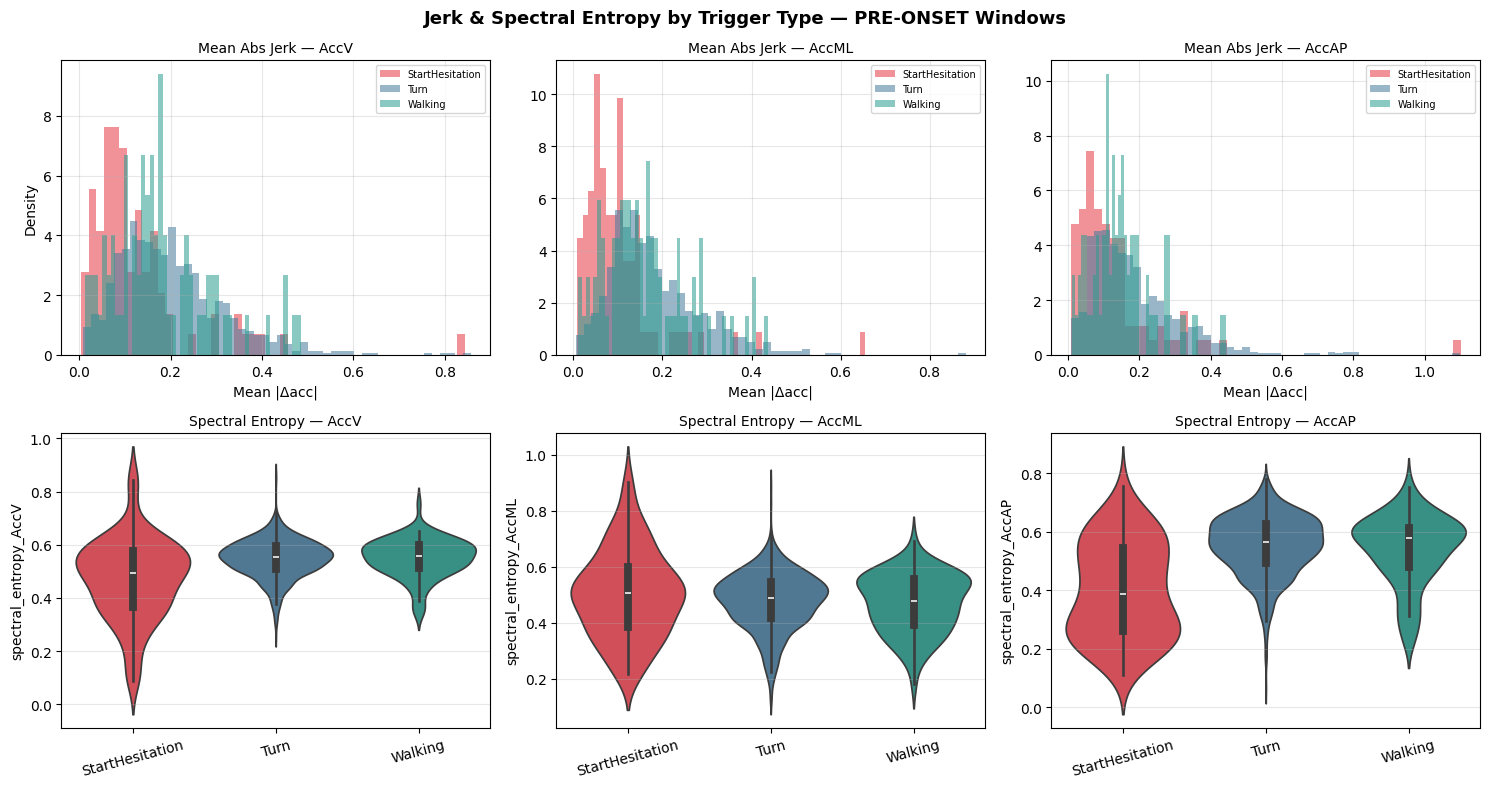

In [9]:
fig, axes_grid = plt.subplots(2, 3, figsize=(15, 8))

for col, ax_name in enumerate(AXES):

    # Jerk
    ax = axes_grid[0][col]
    for trig in TRIGGER_TYPES:
        vals = feat_df[feat_df["trigger"] == trig][f"mean_abs_jerk_{ax_name}"]
        ax.hist(vals, bins=50, alpha=0.55,
                color=COLORS[trig], label=trig, density=True)
    ax.set_title(f"Mean Abs Jerk — {ax_name}", fontsize=10)
    ax.set_xlabel("Mean |Δacc|")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel("Density")

    # Spectral entropy
    ax = axes_grid[1][col]
    sns.violinplot(data=feat_df, x="trigger",
                   y=f"spectral_entropy_{ax_name}",
                   palette=COLORS, order=TRIGGER_TYPES,
                   inner="box", ax=ax)
    ax.set_title(f"Spectral Entropy — {ax_name}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Jerk & Spectral Entropy by Trigger Type — PRE-ONSET Windows",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3330/3884545665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=feat_df, x="trigger", y=f"corr_{a}_{b}",
/tmp/ipykernel_3330/3884545665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=feat_df, x="trigger", y=f"corr_{a}_{b}",
/tmp/ipykernel_3330/3884545665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=feat_df, x="trigger", y=f"corr_{a}_{b}",


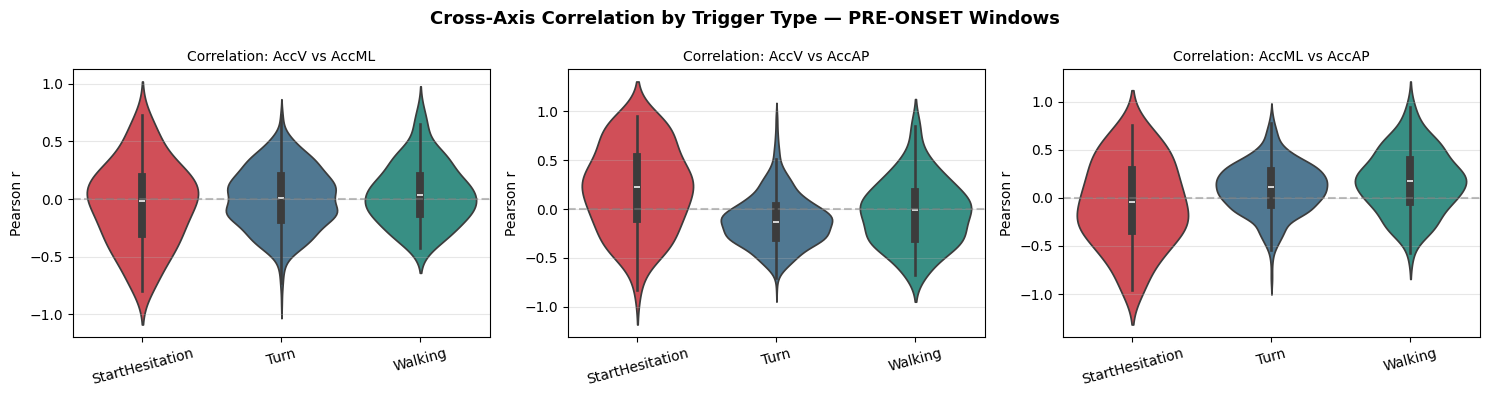

In [10]:
corr_pairs = [("AccV","AccML"), ("AccV","AccAP"), ("AccML","AccAP")]

fig, axes_grid = plt.subplots(1, 3, figsize=(15, 4))

for col, (a, b) in enumerate(corr_pairs):
    ax = axes_grid[col]
    sns.violinplot(data=feat_df, x="trigger", y=f"corr_{a}_{b}",
                   palette=COLORS, order=TRIGGER_TYPES,
                   inner="box", ax=ax)
    ax.set_title(f"Correlation: {a} vs {b}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Pearson r")
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(0, linestyle='--', color='gray', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Cross-Axis Correlation by Trigger Type — PRE-ONSET Windows",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
feature_cols = [c for c in feat_df.columns if c != "trigger"]

summary = feat_df.groupby("trigger")[feature_cols].mean().T
summary.columns.name = None

summary["ratio_SH_Turn"]   = (summary["StartHesitation"] / summary["Turn"]).round(3)
summary["ratio_Walk_Turn"] = (summary["Walking"]         / summary["Turn"]).round(3)

# Highlight features with the largest separation
summary["max_ratio_deviation"] = summary[["ratio_SH_Turn","ratio_Walk_Turn"]].apply(
    lambda row: max(abs(row["ratio_SH_Turn"] - 1),
                    abs(row["ratio_Walk_Turn"] - 1)), axis=1
).round(3)

summary_sorted = summary.sort_values("max_ratio_deviation", ascending=False)

print("=" * 90)
print("MEAN FEATURE VALUES PER TRIGGER — sorted by separation from Turn")
print("=" * 90)
print(summary_sorted.to_string(float_format="{:.4f}".format))


MEAN FEATURE VALUES PER TRIGGER — sorted by separation from Turn
                        StartHesitation    Turn  Walking  ratio_SH_Turn  ratio_Walk_Turn  max_ratio_deviation
corr_AccV_AccML                 -0.0461  0.0062   0.0427        -7.4000           6.8520               8.4000
var_AccAP                        2.9214  0.6720   0.5966         4.3470           0.8880               3.3470
corr_AccV_AccAP                  0.2064 -0.1166  -0.0354        -1.7700           0.3030               2.7700
corr_AccML_AccAP                -0.0551  0.1020   0.1719        -0.5400           1.6850               1.5400
var_AccML                        0.4098  1.0819   1.0573         0.3790           0.9770               0.6210
dom_freq_AccAP                   1.2713  2.7371   1.8734         0.4640           0.6840               0.5360
dom_freq_AccV                    1.7829  3.8247   3.6118         0.4660           0.9440               0.5340
energy_AccAP                     9.1768  6.3558   8.497